# Trash Classification using ResNet and Transfer Learning

The dataset used includes images of some target trash we are trying to classify.

## Import Necessary Libraries

In [1]:
# Import Data Science Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split

2025-12-03 21:12:18.218965: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-03 21:12:20.764943: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Tensorflow Libraries
from tensorflow import keras
from tensorflow.keras import layers,models
from keras.utils import image_dataset_from_directory
from keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import Callback, EarlyStopping,ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model
from tensorflow.keras.layers import Resizing, Rescaling
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

In [3]:
print(tf.__version__)
print(keras.__version__)

2.16.1
3.3.3


In [4]:
# System libraries
from pathlib import Path
import os.path

In [5]:
# Metrics
from sklearn.metrics import classification_report, confusion_matrix
import itertools

## Create helper functions

In [6]:
# !wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py

# Import series of helper functions for our notebook
from helper_functions import create_tensorboard_callback, plot_loss_curves, unzip_data, compare_historys, walk_through_dir, pred_and_plot

## Load and transform data

In [7]:
BATCH_SIZE = 32
IMAGE_SIZE = (300, 300)

In [8]:
# from google.colab import drive

# drive.mount('/content/drive')

# Walk through each directory
trash = "Dataset"

# Verify files exist
for root, dirs, files in os.walk(trash):
    print(f"Directory: {root}, Subdirs: {len(dirs)}, Files: {len(files)}")

Directory: Dataset, Subdirs: 11, Files: 0
Directory: Dataset/apples, Subdirs: 0, Files: 1190
Directory: Dataset/bananas, Subdirs: 0, Files: 1111
Directory: Dataset/bottles, Subdirs: 0, Files: 1154
Directory: Dataset/cans, Subdirs: 0, Files: 1035
Directory: Dataset/cardboard, Subdirs: 0, Files: 1121
Directory: Dataset/cups, Subdirs: 0, Files: 1138
Directory: Dataset/eggshells, Subdirs: 0, Files: 1136
Directory: Dataset/generalcompost, Subdirs: 0, Files: 1123
Directory: Dataset/mixers, Subdirs: 0, Files: 1129
Directory: Dataset/peels, Subdirs: 0, Files: 1124
Directory: Dataset/tissues, Subdirs: 0, Files: 1132


### Placing data into a Dataframe
The first column `filepaths` contains the file path location of each individual images. The second column `labels`, on the other hand, contains the class label of the corresponding image from the file path

In [9]:
trash_dir = Path(trash)

# Get filepaths and labels
filepaths = list(trash_dir.glob(r'**/*.jpg')) + list(trash_dir.glob(r'**/*.png')) + list(trash_dir.glob(r'**/*.jpeg'))
print(filepaths[:5])

labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

# Concatenate filepaths and labels
image_df = pd.concat([filepaths, labels], axis=1)

[PosixPath('Dataset/apples/apple--1-_jpg.rf.7662faa1233b5fc07d695672f592c04f.jpg'), PosixPath('Dataset/apples/apple--10-_jpg.rf.464143fc334f48eea9338640b7e9714a.jpg'), PosixPath('Dataset/apples/apple--100-_jpg.rf.2e8aaf48f79352b7cf59c1dba9268d26.jpg'), PosixPath('Dataset/apples/apple--101-_jpg.rf.fd7654247c4fb89861e18f19ac52e746.jpg'), PosixPath('Dataset/apples/apple--102-_jpg.rf.d7b9391de2039517883879d18a3dc38f.jpg')]


In [10]:
# bad_files = []

# print(f"Checking {len(filepaths)} images...")

# for fp in filepaths:
#     path = str(fp)
#     try:
#         # Read bytes from disk
#         img_bytes = tf.io.read_file(path)

#         # Try to decode using TensorFlow
#         _ = tf.image.decode_image(img_bytes, channels=3)
#         # print(f"✅ {path} is a valid image")

#     except Exception as e:
#         print(f"⚠️  Unreadable image: {path}")
#         print(f"    Error: {e}")
#         bad_files.append(path)

# print(f"\nTotal unreadable files: {len(bad_files)}")

In [11]:
image_df

,Filepath,Label
0,Dataset/apples/apple--1-_jpg.rf.7662faa1233b5f...,apples
1,Dataset/apples/apple--10-_jpg.rf.464143fc334f4...,apples
2,Dataset/apples/apple--100-_jpg.rf.2e8aaf48f793...,apples
3,Dataset/apples/apple--101-_jpg.rf.fd7654247c4f...,apples
4,Dataset/apples/apple--102-_jpg.rf.d7b9391de203...,apples
...,...,...
12351,Dataset/tissues/tissue8 copy.jpeg,tissues
12352,Dataset/tissues/tissue8.jpeg,tissues
12353,Dataset/tissues/tissue9 copy 2.jpeg,tissues
12354,Dataset/tissues/tissue9 copy.jpeg,tissues


### Visualizing images from the dataset

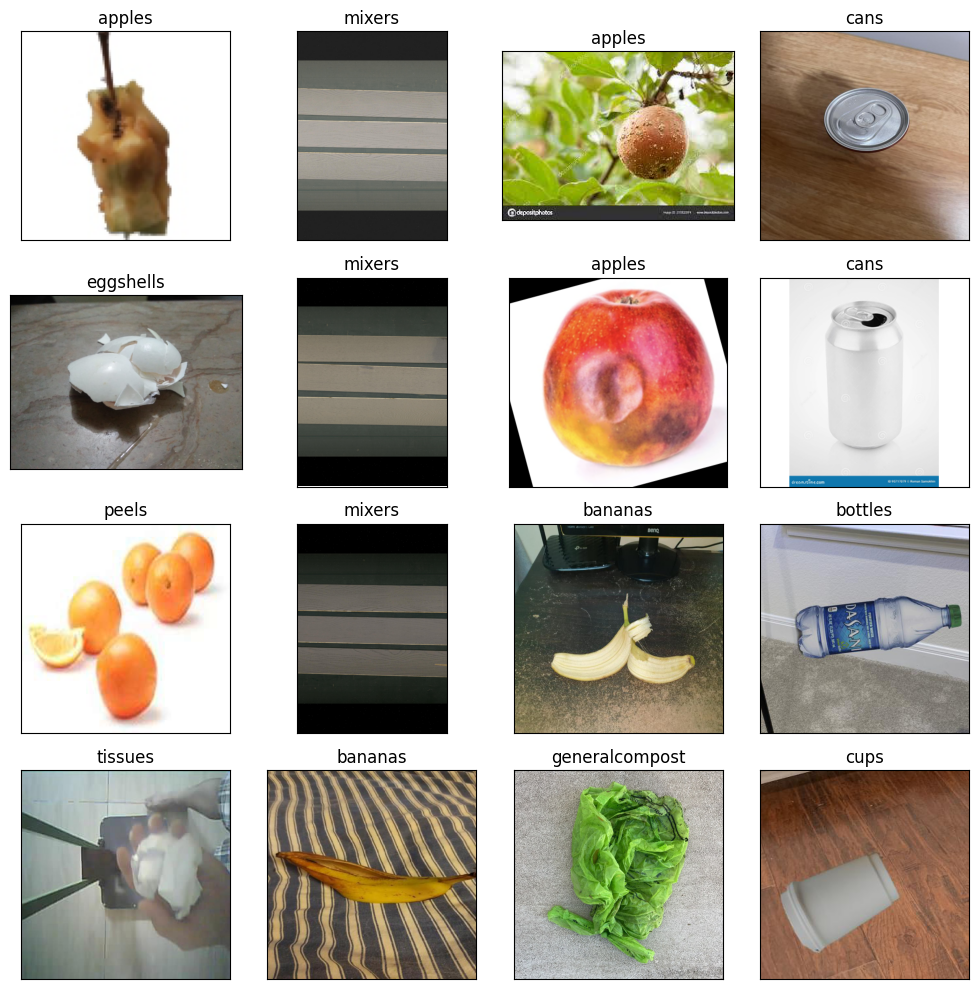

In [12]:
# Display 16 picture of the dataset with their labels
random_index = np.random.randint(0, len(image_df), 16)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 10),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(image_df.Filepath[random_index[i]]))
    ax.set_title(image_df.Label[random_index[i]])
plt.tight_layout()
plt.show()

## Data Preprocessing
The data will be split into three different categories: Training, Validation and Testing. The training data will be used to train the deep learning CNN model and its parameters will be fine tuned with the validation data. Finally, the performance of the data will be evaluated using the test data(data the model has not previously seen).

In [13]:
# 80% train, 10% validation, 10% test

# label_mode = "int" produces labels like [0, 1, 0, 1, ...] which does not match with loss='categorical_crossentropy' when training the model

train_ds = image_dataset_from_directory(
    directory=trash_dir,
    labels='inferred',
    label_mode='categorical', # produces one-hot labels like [[1,0],[0,1],...] suits loss = 'categorical_crossentropy'
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(224, 224),     # must match model input
    batch_size=32
)

val_ds = image_dataset_from_directory(
    directory=trash_dir,
    labels='inferred',
    label_mode='categorical',
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

# Split val into two, val and test
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

Found 12392 files belonging to 11 classes.
Using 9914 files for training.
Found 12392 files belonging to 11 classes.
Using 2478 files for validation.


In [14]:
# To decide order of class_names in app.py
class_names = train_ds.class_names
class_names

['apples',
 'bananas',
 'bottles',
 'cans',
 'cardboard',
 'cups',
 'eggshells',
 'generalcompost',
 'mixers',
 'peels',
 'tissues']

In [15]:
# # Resize Layer: Causing issues with model upload to repo and training
# resize_and_rescale = tf.keras.Sequential([
#   Resizing(224,224),
#   Rescaling(preprocess_input),
#   layers.RandomFlip("horizontal_and_vertical"),
#   layers.RandomRotation(0.2),
#   layers.RandomZoom(0.2),
#   layers.RandomContrast(0.2),
#   layers.RandomBrightness(0.2)
# ])

## Training the model
The model images will be subjected to a pre-trained CNN model called MobileNetV2. Three callbacks will be utilized to monitor the training. These are: Model Checkpoint, Early Stopping, Tensorboard callback. The summary of the model hyperparameter is shown as follows:

**Batch size** : 32

**Epochs** : 100

**Input Shape** : (224, 224, 3)

**Output layer** : 2



In [16]:
# Load the pretained model
pretrained_model = ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

# pretrained_model.trainable = False

### Training the model

In [17]:
# Phase 1
# Uses features ResNet has from imagenet (edges, shapes, textures, etc) to map them to our targets

# inputs = pretrained_model.input

inputs = tf.keras.Input(shape=(224, 224, 3))

# x = resize_and_rescale(inputs)
x = tf.keras.layers.Resizing(224, 224)(inputs)
x = tf.keras.layers.Normalization()(x)
# x = tf.keras.layers.Lambda(preprocess_input)(x)

x = pretrained_model(x, training=False)

x = Dense(256, activation='relu')(x)
# (pretrained_model.output)
x = Dropout(0.2)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)


outputs = Dense(11, activation='softmax')(x) #4 targets so far

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy', # label_mode = 'categorical'
    metrics=['accuracy']
)

# Setup EarlyStopping callback to stop training if model's val_loss doesn't improve for 3 epochs
early_stopping_1 = EarlyStopping(monitor = "val_accuracy", # watch the val loss metric
                               patience = 2,
                               restore_best_weights = True,
                               mode="max") # if val accuracy increases for 5 epochs in a row, stop training. mode max tells keras the higher the better

# Create checkpoint callback
checkpoint_path_1 = "checkpoints/trash_model_phase1_checkpoint.weights.h5"
checkpoint_callback_1 = ModelCheckpoint(checkpoint_path_1,
                                      save_weights_only=True,
                                      monitor="val_accuracy",
                                      save_best_only=True,
                                      verbose=1) #1 gives more information while training and 0 gives less (no progress bar)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        early_stopping_1,
        checkpoint_callback_1,
    ]
)

Epoch 1/30
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7882 - loss: 0.7079
Epoch 1: val_accuracy improved from -inf to 0.95691, saving model to checkpoints/trash_model_phase1_checkpoint.weights.h5
310/310 ━━━━━━━━━━━━━━━━━━━━ 972s 3s/step - accuracy: 0.7886 - loss: 0.7067 - val_accuracy: 0.9569 - val_loss: 0.1500
Epoch 2/30
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9722 - loss: 0.0989
Epoch 2: val_accuracy improved from 0.95691 to 0.95772, saving model to checkpoints/trash_model_phase1_checkpoint.weights.h5
310/310 ━━━━━━━━━━━━━━━━━━━━ 942s 3s/step - accuracy: 0.9722 - loss: 0.0989 - val_accuracy: 0.9577 - val_loss: 0.1743
Epoch 3/30
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9871 - loss: 0.0476
Epoch 3: val_accuracy improved from 0.95772 to 0.97398, saving model to checkpoints/trash_model_phase1_checkpoint.weights.h5
310/310 ━━━━━━━━━━━━━━━━━━━━ 937s 3s/step - accuracy: 0.9871 - loss: 0.0476 - val_accuracy: 0.9740 - val_loss: 0.1209
Epoch 4/30
310/310 

In [18]:
# Phase 2
# Specializes the dataset for our dataset by training deeper layers

pretrained_model.trainable = True

for layer in pretrained_model.layers[:-30]: # freeze lower conv blocks.
    layer.trainable = False

model.compile(
    optimizer=Adam(0.00001),
    loss='categorical_crossentropy', # label_mode = 'categorical'
    metrics=['accuracy']
)

# Setup EarlyStopping callback to stop training if model's val_loss doesn't improve for 3 epochs
early_stopping_2= EarlyStopping(monitor = "val_accuracy", # watch the val loss metric
                               patience = 2,
                               restore_best_weights = True,
                               mode="max") # if val accuracy increases for 5 epochs in a row, stop training. mode max tells keras the higher the better

# Create checkpoint callback
checkpoint_path_2 = "checkpoints/trash_model_phase2_checkpoint.weights.h5"
checkpoint_callback_2 = ModelCheckpoint(checkpoint_path_2,
                                      save_weights_only=True,
                                      monitor="val_accuracy",
                                      save_best_only=True,
                                      verbose=1) #1 gives more information while training and 0 gives less (no progress bar)


history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        early_stopping_2,
        checkpoint_callback_2,
    ]
)

Epoch 1/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 836ms/step - accuracy: 0.9945 - loss: 0.0128
Epoch 1: val_accuracy improved from -inf to 0.98699, saving model to checkpoints/trash_model_phase2_checkpoint.weights.h5
310/310 ━━━━━━━━━━━━━━━━━━━━ 294s 916ms/step - accuracy: 0.9946 - loss: 0.0127 - val_accuracy: 0.9870 - val_loss: 0.0430
Epoch 2/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - accuracy: 0.9974 - loss: 0.0066
Epoch 2: val_accuracy improved from 0.98699 to 0.98943, saving model to checkpoints/trash_model_phase2_checkpoint.weights.h5
310/310 ━━━━━━━━━━━━━━━━━━━━ 286s 921ms/step - accuracy: 0.9974 - loss: 0.0066 - val_accuracy: 0.9894 - val_loss: 0.0359
Epoch 3/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 837ms/step - accuracy: 0.9988 - loss: 0.0047
Epoch 3: val_accuracy did not improve from 0.98943
310/310 ━━━━━━━━━━━━━━━━━━━━ 282s 909ms/step - accuracy: 0.9988 - loss: 0.0047 - val_accuracy: 0.9870 - val_loss: 0.0364
Epoch 4/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 834ms/step - accuracy: 0.9995 - 

## Model Evaluation
The test dataset will be used to evaluate the performance of the model.One of the metrics that will be tested would be accuracy which measures the fraction of predictions the model got right. Other metrics are as follows:

**Precision(P)**:
The fraction of true positives (TP, correct predictions) from the total amount of relevant results, i.e., the sum of TP and false positives (FP). For multi-class classification problems, P is averaged among the classes. The following is the formula for precision.

<center>$P=TP/(TP+FP)$</center>

**Recall(R)**:
The fraction of TP from the total amount of TP and false negatives (FN). For multi-class classification problems, R gets averaged among all the classes. The following is the formula for recall.
<center>$R=TP/(TP+FN)$</center>

**F1 score(F1)**:
The harmonic mean of precision and recall. For multi-class classification problems, F1 gets averaged among all the classes. The following is the formula for F1 score.
<center>$F1=2 * (TP * FP)/(TP+FP)$</center>



In [19]:
results = model.evaluate(test_ds, verbose=0)

print("    Test Loss: {:.5f}".format(results[0]))
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

test_loss, test_acc = model.evaluate(test_ds)
print(f"Unbiased test accuracy: {test_acc:.4f}")

    Test Loss: 0.05390
Test Accuracy: 98.80%
39/39 ━━━━━━━━━━━━━━━━━━━━ 22s 573ms/step - accuracy: 0.9850 - loss: 0.0754
Unbiased test accuracy: 0.9896


In [20]:
model.save("trashclassify.keras")
model.save_weights("trashclassify_weights.weights.h5")
print("Files saved!")

Files saved!


In [21]:
for layer in model.layers:
    print(layer.name, type(layer))

input_layer_1 <class 'keras.src.layers.core.input_layer.InputLayer'>
resizing <class 'keras.src.layers.preprocessing.resizing.Resizing'>
normalization <class 'keras.src.layers.preprocessing.normalization.Normalization'>
resnet50 <class 'keras.src.models.functional.Functional'>
dense <class 'keras.src.layers.core.dense.Dense'>
dropout <class 'keras.src.layers.regularization.dropout.Dropout'>
dense_1 <class 'keras.src.layers.core.dense.Dense'>
dropout_1 <class 'keras.src.layers.regularization.dropout.Dropout'>
dense_2 <class 'keras.src.layers.core.dense.Dense'>


### Visualizing loss curves

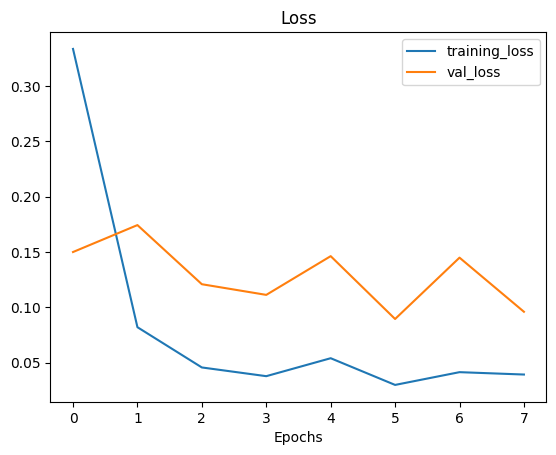

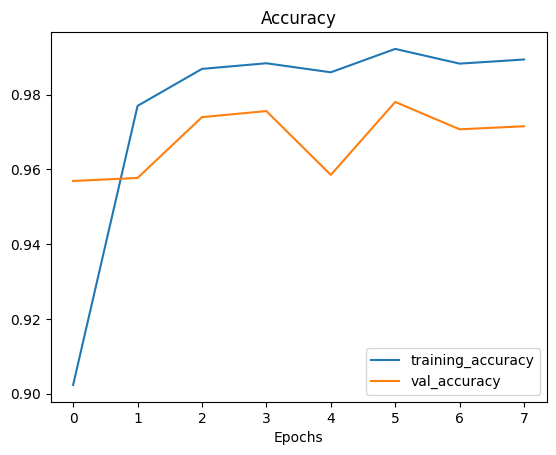

In [22]:
plot_loss_curves(history)

### Making predictions on the test data

In [23]:
# Predict the label of the test_images
pred = model.predict(test_ds)
pred = np.argmax(pred,axis=1)

# Map the label
class_names = (train_ds.class_names)
pred_labels = [class_names[i] for i in pred]

# Display the result
print(f'The first 5 predictions: {pred_labels[:5]}')

39/39 ━━━━━━━━━━━━━━━━━━━━ 24s 563ms/step
The first 5 predictions: ['cups', 'bananas', 'apples', 'cups', 'peels']


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


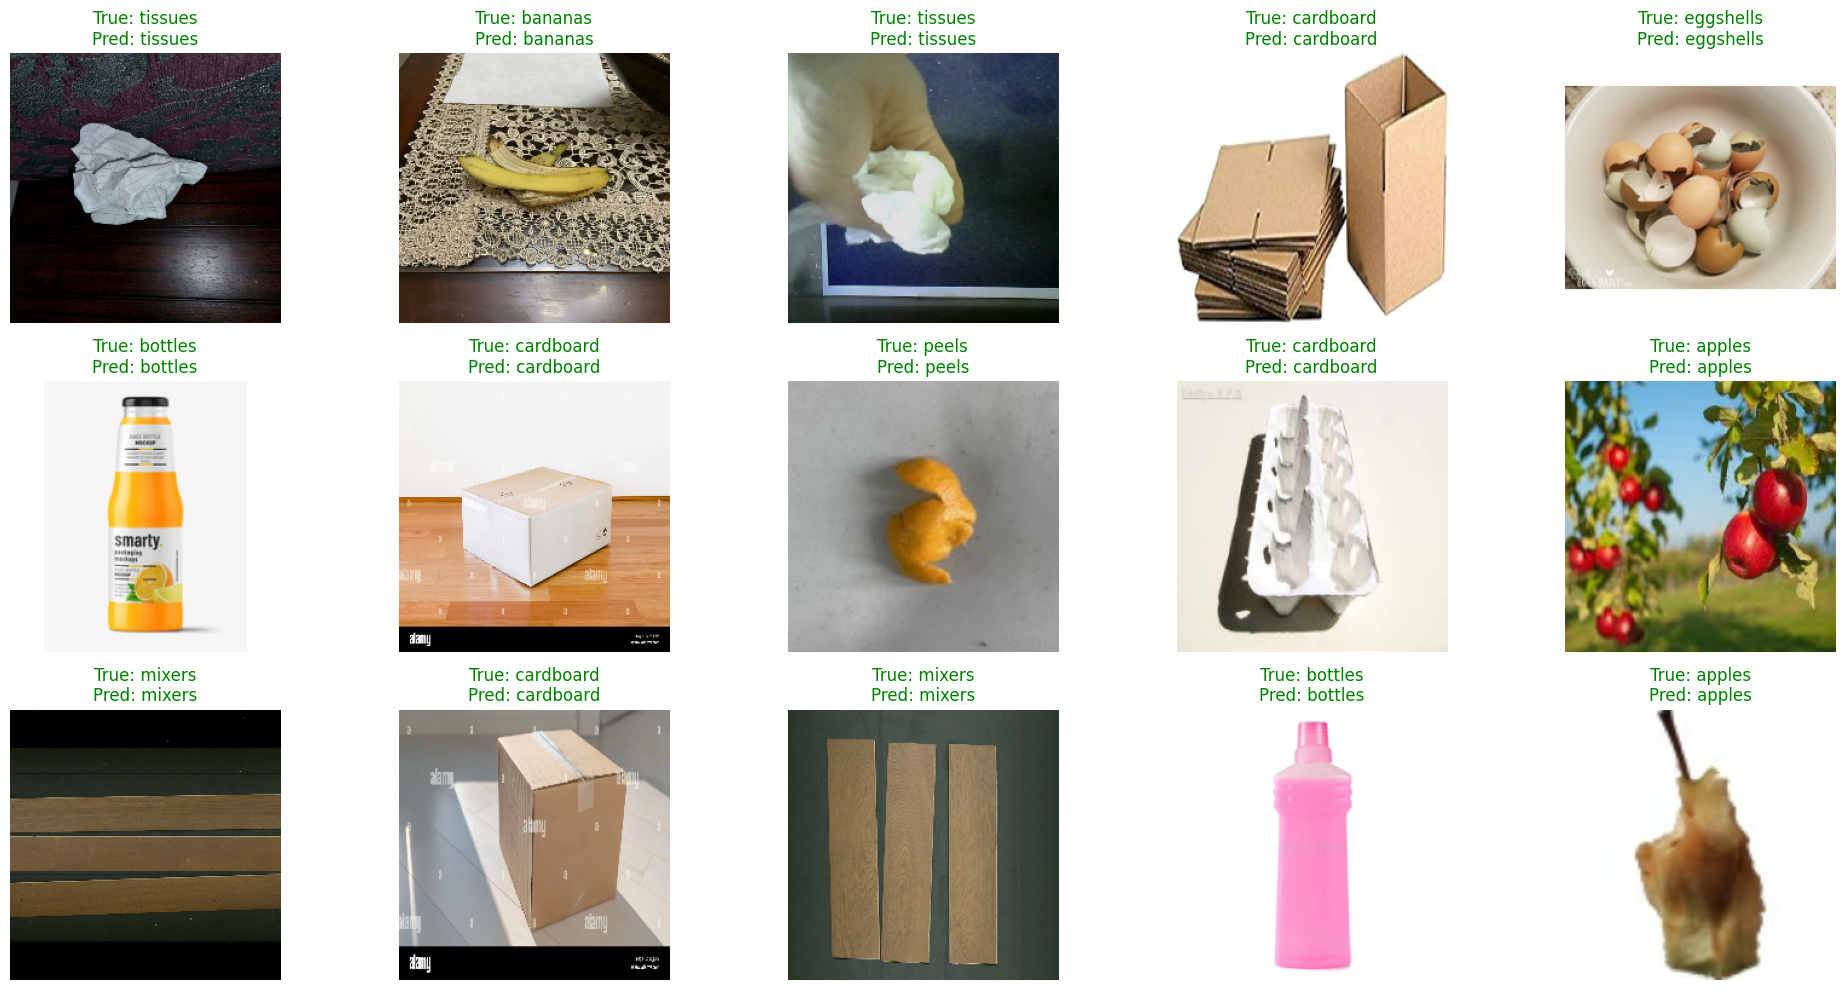

2025-12-03 23:45:48.903763: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [24]:
# Display 25 random pictures from the dataset with their labels
# Take one batch of images and labels

y_true = []
y_pred = []

for images, labels in test_ds.take(1): # 1 specifies 1 batch of 32 images since that is our batch size. len(test_ds) all test images
    preds = model.predict(images)

    batch_pred = np.argmax(preds, axis=1)
    batch_true = np.argmax(labels.numpy(), axis=1)
    
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))  # if one-hot encoded
    # class_names = test_ds.class_names

    plt.figure(figsize=(20, 10))
    for i in range(15):  # show first 15 images
        ax = plt.subplot(3, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        color = "green" if batch_pred[i] == batch_true[i] else "red"
        plt.title(f"True: {class_names[batch_true[i]]}\nPred: {class_names[batch_pred[i]]}", color=color)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

### Plotting the classification reports and confusion matrix

In [25]:
# Extract all true labels from test_ds
# y_true = []
# for _, labels in test_ds:
#     y_true.extend(np.argmax(labels.numpy(), axis=1))  # if one-hot encoded

# # Get predictions for all batches
# pred_probs = model.predict(test_ds)
# y_pred = np.argmax(pred_probs, axis=1) # do not use if label_mode = "int"

# Generate report
print(classification_report(y_true, y_pred, target_names=class_names))

                precision    recall  f1-score   support

        apples       1.00      1.00      1.00         3
       bananas       1.00      1.00      1.00         5
       bottles       1.00      1.00      1.00         2
          cans       1.00      1.00      1.00         2
     cardboard       1.00      1.00      1.00         4
          cups       1.00      1.00      1.00         1
     eggshells       1.00      1.00      1.00         3
generalcompost       1.00      1.00      1.00         2
        mixers       1.00      1.00      1.00         4
         peels       1.00      1.00      1.00         3
       tissues       1.00      1.00      1.00         3

      accuracy                           1.00        32
     macro avg       1.00      1.00      1.00        32
  weighted avg       1.00      1.00      1.00        32



In [26]:
#Create readable class names
# class_names = test_ds.class_names

#Generate the classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

#Convert to DataFrame for display
df = pd.DataFrame(report).transpose()
display(df)

,precision,recall,f1-score,support
apples,1.0,1.0,1.0,3.0
bananas,1.0,1.0,1.0,5.0
bottles,1.0,1.0,1.0,2.0
cans,1.0,1.0,1.0,2.0
cardboard,1.0,1.0,1.0,4.0
cups,1.0,1.0,1.0,1.0
eggshells,1.0,1.0,1.0,3.0
generalcompost,1.0,1.0,1.0,2.0
mixers,1.0,1.0,1.0,4.0
peels,1.0,1.0,1.0,3.0


In [27]:
def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(15, 7), text_size=10, norm=False, savefig=False):
  """Makes a labelled confusion matrix comparing predictions and ground truth labels.

  If classes is passed, confusion matrix will be labelled, if not, integer class values
  will be used.

  Args:
    y_true: Array of truth labels (must be same shape as y_pred).
    y_pred: Array of predicted labels (must be same shape as y_true).
    classes: Array of class labels (e.g. string form). If `None`, integer labels are used.
    figsize: Size of output figure (default=(10, 10)).
    text_size: Size of output figure text (default=15).
    norm: normalize values or not (default=False).
    savefig: save confusion matrix to file (default=False).

  Returns:
    A labelled confusion matrix plot comparing y_true and y_pred.

  Example usage:
    make_confusion_matrix(y_true=test_labels, # ground truth test labels
                          y_pred=y_preds, # predicted labels
                          classes=class_names, # array of class label names
                          figsize=(15, 15),
                          text_size=10)
  """
  # Create the confustion matrix
  cm = confusion_matrix(y_true, y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize it
  n_classes = cm.shape[0] # find the number of classes we're dealing with

  # Plot the figure and make it pretty
  fig, ax = plt.subplots(figsize=figsize)
  cax = ax.matshow(cm, cmap=plt.cm.Blues) # colors will represent how 'correct' a class is, darker == better
  fig.colorbar(cax)

  # Are there a list of classes?
  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  # Label the axes
  ax.set(title="Confusion Matrix",
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes), # create enough axis slots for each class
         yticks=np.arange(n_classes),
         xticklabels=labels, # axes will labeled with class names (if they exist) or ints
         yticklabels=labels)

  # Make x-axis labels appear on bottom
  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()
  ### Added: Rotate xticks for readability & increase font size (required due to such a large confusion matrix)
  plt.xticks(rotation=90, fontsize=text_size)
  plt.yticks(fontsize=text_size)

  # Set the threshold for different colors
  threshold = (cm.max() + cm.min()) / 2.

  # Plot the text on each cell
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    if norm:
      plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)
    else:
      plt.text(j, i, f"{cm[i, j]}",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)

  # Save the figure to the current working directory
  if savefig:
    fig.savefig("confusion_matrix.png")


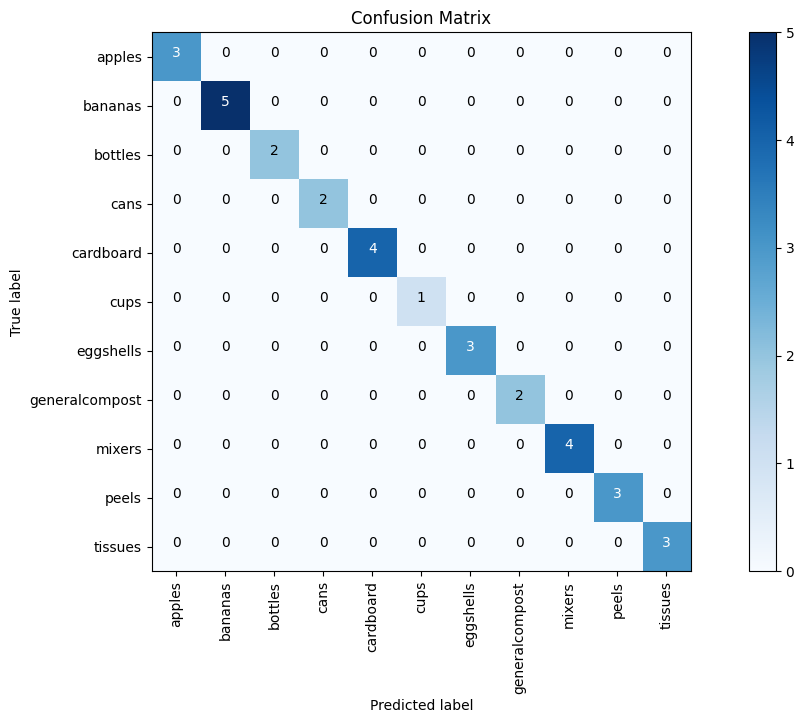

In [28]:
make_confusion_matrix(y_true, y_pred, class_names)